### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/phy_prod_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/phy_prod_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [4]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [5]:
Phy_Prod_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Physical Production",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
Phy_Prod_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
89,46_0_0_0_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",39,"""Export control was a failure."" Nvidia CEO Jen..."
94,46_1_0_9_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",39,"So there are lots of startups in China, GPU co..."


In [6]:
print(len(Phy_Prod_chunks))

16576


### Bertopic

In [ ]:
# ! pip install bertopic

In [6]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small" , device="cuda")

umap_model = UMAP(
    n_neighbors=80, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=15, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

# 100,20
hdbscan_model = HDBSCAN(
    min_cluster_size=150, # smaller min_cluster_size will -> more detailed topics
    min_samples=40, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
docs = Phy_Prod_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [8]:
Phy_Prod_topics = topic_model.get_topic_info()
Phy_Prod_chunks_topics = Phy_Prod_chunks.assign( topic=topics,  probability=probs)

In [25]:
show_full(Phy_Prod_topics[ ["Topic", 'Representation', "Count"]])

,Topic,Representation,Count
0,-1,"[symbols, smart portfolio, cores, tipranks, npu, separated spaces, paste multiple, copy paste, core ultra, paste]",155
1,0,"[air conditioners, conditioners, uhd, qned, webos, dolby, soundbar, conditioner, filmmaker, air conditioner]",4484
2,1,"[oppo, vivo, phones mobile, hindustantimes, galaxy series, xiaomi, motorola, gta, mobiles, com tech]",2984
3,2,"[mobility, fleet, automotive industry, bmw, mercedes-benz, volkswagen, automotive industries, dealers, mercedes, digital digital]",2145
4,3,"[huawei, chips china, export controls, commerce, national security, advanced chips, jensen, curbs, jensen huang, trump administration]",1390
5,4,"[farmers, crop, farming, agricultural, farm, soil, crops, agriculture market, farms, intelligence agriculture]",869
6,5,"[msi, acer, zen, core ultra, intel core, strix, ryzen series, npu, cores, ryzen max]",850
7,6,"[instinct, amd stock, amd instinct, lisa, ceo lisa, amd shares, epyc, nasdaq amd, devices amd, rocm]",652
8,7,"[drill, drilling, exploration, samples, mineral, holes, forward-looking, hole, zone, meters]",579
9,8,"[taiwan semiconductor, asml, motley, fool, motley fool, semiconductor manufacturing, tsm, stock advisor, recommends, broadcom]",565


In [81]:
Phy_Prod_topics.to_csv(f"{DATA_DIR}/Phy_Prod_specific/Phy_Prod_topics.csv", index=False)
Phy_Prod_chunks_topics.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/Phy_Prod_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [8]:
Phy_Prod_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/Phy_Prod_chunks_topics.parquet")

In [9]:
manual_category_topics = {'High_Tech_Production': [2, 3, 8, 9, 10, 11, 12],'Traditional_Production': [4,7]} # most are noise

df_high_tech = Phy_Prod_chunks_topics[Phy_Prod_chunks_topics['topic'].isin(manual_category_topics['High_Tech_Production'])]
df_traditional = Phy_Prod_chunks_topics[Phy_Prod_chunks_topics['topic'].isin(manual_category_topics['Traditional_Production'])]

print(f"\n# of df_high_tech chunks: {len(df_high_tech)}")
print(f"# of df_traditional chunks: {len(df_traditional)}")


# of df_high_tech chunks: 5784
# of df_traditional chunks: 1448


In [10]:
df_high_tech.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/psyprod_df_high_tech.parquet", index=False)
df_traditional.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/psyprod_df_traditional.parquet", index=False)

### Sentiment Analysis on chunk level

#### high tech production industry

##### 1. use LLM to generate 100 labels

In [11]:
df_high_tech['topic'].value_counts()    

topic
2     2145
3     1390
8      565
9      543
10     452
11     414
12     275
Name: count, dtype: int64

In [12]:
df_high_tech_sample = pd.concat([
    df_high_tech[df_high_tech["topic"] == 2].sample(180, random_state=38),
    df_high_tech[df_high_tech["topic"] == 3].sample(120, random_state=38),
    df_high_tech[df_high_tech["topic"] == 8].sample(70, random_state=38),
    df_high_tech[df_high_tech["topic"] == 9].sample(70, random_state=38),
    df_high_tech[df_high_tech["topic"] == 10].sample(50, random_state=38),
    df_high_tech[df_high_tech["topic"] == 11].sample(50, random_state=38),
    df_high_tech[df_high_tech["topic"] == 12].sample(30, random_state=38),        
])[["chunk_uid", "topic", "chunk_text"]].reset_index(drop=True)

print(len(df_high_tech_sample))

570


In [13]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [14]:
system_msg = """
You are an expert analyst of high-tech production industries.

Your task is to evaluate how the high-tech production industries and their companies
described in the text are expected to be impacted by AI or AI-related developments.

High-tech production industries include sectors such as:
- semiconductor manufacturing
- AI chips and GPUs
- advanced electronics and smartphones
- robotics and automation hardware
- electric vehicles and autonomous driving hardware
- advanced computing hardware and data-center infrastructure

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
   The text suggests that AI or AI-related technologies are expected to benefit the
   high-tech production industry or its companies.

   Examples include:
   - increased demand for AI chips or computing hardware
   - expansion of semiconductor manufacturing
   - revenue growth driven by AI products
   - technological leadership in AI hardware
   - new product opportunities in AI-related hardware
   - increased investment in advanced manufacturing


2. "negatively"
   The text suggests that AI or AI-related developments are expected to harm or constrain
   the high-tech production industry or its companies.

   Examples include:
   - export restrictions on AI chips
   - geopolitical limits on semiconductor sales
   - supply chain disruptions affecting AI hardware
   - sanctions or regulation restricting advanced chip production
   - competitive pressure reducing market share
   - technological disadvantages or production setbacks


3. "hard-to-say"
   The text is neutral, mixed, uncertain, speculative, or descriptive without a clear directional impact. Or the text is irrelevant to AI on industry impact.

   Examples include:
   - factual reporting about industry news and developments without clear AI impact
   - mixed opportunities and risks
   - policy or geopolitical discussion without clear winners or losers
   - announcements without clear economic consequences


### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- If both benefits and risks are discussed without a clear dominant direction,
  choose "hard-to-say".
- If the text mainly describes events, announcements, or policies without clear
  industry impact, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""

impact_user_template = """
Here is a text segment discussing companies or industries in the high-tech production sector:

{chunk_text}

Please determine whether the described industry or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI or AI-related developments.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [15]:
from jsonschema import validate, ValidationError
VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback
    
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)
    

In [16]:
train_ai_impact_label = []

for idx, row in df_high_tech_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [17]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
positively     299
hard-to-say    197
negatively      74
Name: count, dtype: int64

['94934_0_0_0_0', '132911_0_0_0_2', '134857_0_0_0_0', '143054_1_0_0_2', '127135_1_1_0_0', '94760_0_0_0_0', '97400_0_2_0_0', '134403_0_1_1_0', '139449_0_1_0_0', '92888_0_0_0_0', '23020_0_0_0_0', '141918_0_0_0_0', '95679_0_0_0_0', '133115_0_0_0_0', '132461_1_0_0_1', '71454_0_1_0_0', '9573_0_0_0_1', '97400_0_0_0_0', '33433_1_1_0_0', '32964_1_0_0_0', '132142_0_0_0_1', '134491_0_0_1_0', '117185_0_0_0_0', '95840_0_0_0_1', '133141_0_0_0_2', '143096_0_0_0_0', '37401_0_1_0_1', '146646_0_0_0_0', '97400_0_0_0_2', '132461_1_1_0_0', '134709_0_0_0_1', '133044_0_0_0_1', '133171_0_0_0_0', '37401_0_1_0_0', '52097_0_0_0_1', '95899_0_0_0_1', '102796_0_1_0_0', '74881_0_0_0_0', '95837_0_0_0_0', '24178_3_1_1_0', '95286_0_0_0_0', '95853_0_0_0_1', '135232_0_0_0_0', '95293_0_0_0_0', '74872_0_0_0_0', '132315_1_0_0_1', '9573_1_0_0_0', '134522_0_0_0_1', '90364_0_0_0_0', '22826_0_1_1_0', '134813_0_1_1_1', '32822_1_0_0_0', '94879_0_0_0_0', '132315_0_0_0_1', '32643_0_0_0_0', '144253_0_0_0_0', '134452_0_0_0_1', '1348

In [20]:
df_train_ai_impact_label.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/phy_prod_ai_impact_train.parquet", index=False)

##### 2. finetune classifer

In [3]:
df_train_hightech = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/phy_prod_ai_impact_train.parquet")
display(df_train_hightech['impact_label'].value_counts())

,count
impact_label,
positively,299
hard-to-say,197
negatively,74


In [4]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train_hightech = (
    df_train_hightech.loc[df_train_hightech["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train_hightech["label"] = df_train_hightech["impact_label"].map(label2id)
df_train_hightech = df_train_hightech[["text", "label"]].reset_index(drop=True)

df_train_hightech.head()

,text,label
0,Gatik's new AI Research Group gains momentum w...,2
1,About Barrett-Jackson\n\nEstablished in 1971 a...,1
2,Battery cell know-how along the entire value c...,1
3,ACV Panels Discuss using AI for Trusted Vehicl...,1
4,Request Sample of our comprehensive report now...,2


In [ ]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train_hightech, test_size=0.15, random_state=42, stratify=df_train_hightech["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict_hightech = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict_hightech

label
2    239
1    158
0     59
Name: count, dtype: int64
label
2    60
1    39
0    15
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 456
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 114
    })
})

In [12]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict_hightech.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 484
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 86
    })
})

In [13]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "phyprod_hightech_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [14]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.898832,0.534884,0.269571,0.398929,0.348148
2,0.933234,0.743292,0.674419,0.549105,0.774768,0.530976
3,0.933234,0.646104,0.744186,0.740827,0.751871,0.731313
4,0.680973,0.640479,0.744186,0.729102,0.776950,0.701010
5,0.495159,0.618138,0.744186,0.735992,0.772792,0.712121
6,0.495159,0.616265,0.790698,0.800365,0.841355,0.775758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/phy_prod_models/phyprod_hightech_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/phy_prod_models/phyprod_hightech_classifier/tokenizer.json')

In [15]:
eval_result = trainer.evaluate()
print(eval_result)

{'eval_loss': 0.6162654757499695, 'eval_accuracy': 0.7906976744186046, 'eval_macro_f1': 0.8003646757342796, 'eval_macro_precision': 0.841354723707665, 'eval_macro_recall': 0.7757575757575758, 'eval_runtime': 0.2266, 'eval_samples_per_second': 379.456, 'eval_steps_per_second': 26.474, 'epoch': 6.0}


              precision    recall  f1-score   support

  negatively       1.00      0.73      0.84        11
 hard-to-say       0.71      0.80      0.75        30
  positively       0.82      0.80      0.81        45

    accuracy                           0.79        86
   macro avg       0.84      0.78      0.80        86
weighted avg       0.80      0.79      0.79        86



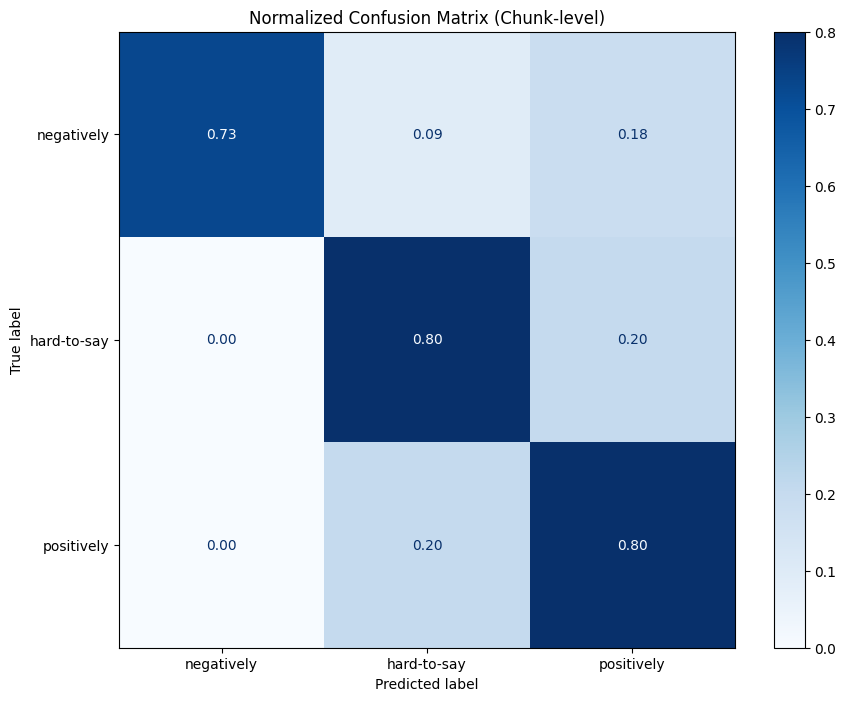

In [16]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_high_tech chunks with the fine tuned model

In [17]:
df_high_tech = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/psyprod_df_high_tech.parquet")
df_high_tech.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,46_0_0_0_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",39,"""Export control was a failure."" Nvidia CEO Jen...",3,1.000000
1,46_1_0_9_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",39,"So there are lots of startups in China, GPU co...",3,1.000000
2,46_1_0_9_1,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",39,So the the the ban on H20 is not effective for...,3,0.674858
3,62_0_0_0_0,https://www.einpresswire.com/article/817904175...,2025-06-01,"""He’s Not Just Building a Chip—He’s Taking the...",121,"""He’s Not Just Building a Chip—He’s Taking the...",9,0.822626
4,62_0_0_0_1,https://www.einpresswire.com/article/817904175...,2025-06-01,"""He’s Not Just Building a Chip—He’s Taking the...",121,He Replaced It. After hitting roadblocks with ...,9,0.575458


In [18]:
print(df_high_tech.shape)

(5784, 8)


In [19]:
from datasets import Dataset

df_high_tech_pred = (
    df_high_tech[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_high_tech_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/5784 [00:00<?, ? examples/s]

In [20]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_high_tech_pred["pred_label_id"] = pred_ids
df_high_tech_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_high_tech_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_high_tech_pred[f"prob_{label_name}"] = probs[:, i]

print(df_high_tech_pred.shape)
df_high_tech_pred.head()

(5784, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,46_0_0_0_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"""Export control was a failure."" Nvidia CEO Jen...",negatively,0.558900,0.558900,0.167321,0.273778
1,46_1_0_9_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"So there are lots of startups in China, GPU co...",positively,0.585994,0.088170,0.325836,0.585994
2,46_1_0_9_1,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,So the the the ban on H20 is not effective for...,positively,0.440902,0.236979,0.322118,0.440902
3,62_0_0_0_0,https://www.einpresswire.com/article/817904175...,2025-06-01,"""He’s Not Just Building a Chip—He’s Taking the...",9,"""He’s Not Just Building a Chip—He’s Taking the...",positively,0.901524,0.035611,0.062866,0.901524
4,62_0_0_0_1,https://www.einpresswire.com/article/817904175...,2025-06-01,"""He’s Not Just Building a Chip—He’s Taking the...",9,He Replaced It. After hitting roadblocks with ...,positively,0.855123,0.060333,0.084545,0.855123


/tmp/ipykernel_31730/216856629.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


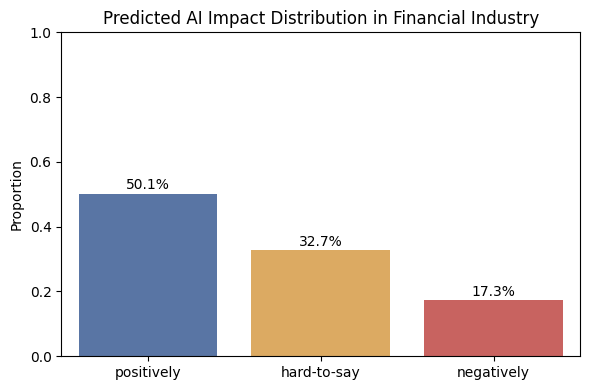

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_high_tech_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in High-Tech Production Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
df_high_tech_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

#### Traditional production

In [24]:
df_traditional = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/psyprod_df_traditional.parquet")

In [25]:
df_traditional['topic'].value_counts()

,count
topic,
4,869
7,579


##### 1. use LLM to generate 100 labels

In [29]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [30]:
df_traditional_sample = pd.concat([
    df_traditional[df_traditional["topic"] == 4].sample(300, random_state=38),
    df_traditional[df_traditional["topic"] == 7].sample(200, random_state=38)
])[["chunk_uid", "topic", "chunk_text"]].reset_index(drop=True)

In [31]:
system_msg = """
You are an expert analyst of traditional physical production industries.

Your task is to evaluate how the traditional production industries and their companies
described in the text are expected to be impacted by AI or AI-related developments.

Traditional production industries include sectors such as:
- agriculture and farming
- food and beverage production
- drilling, mining, and mineral extraction
- oil and gas field operations
- chemicals and industrial materials
- construction materials
- textiles and apparel manufacturing
- basic machinery and conventional manufacturing
- other traditional physical goods production industries

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
   The text suggests that AI or AI-related technologies are expected to benefit the
   traditional production industry or its companies.

   Examples include:
   - improved operational efficiency
   - better forecasting, monitoring, or planning
   - yield improvement in agriculture
   - cost reduction through automation or optimization
   - improved drilling, extraction, or resource allocation
   - productivity gains in manufacturing or supply chains
   - better quality control, maintenance, or logistics


2. "negatively"
   The text suggests that AI or AI-related developments are expected to harm or constrain
   the traditional production industry or its companies.

   Examples include:
   - job displacement caused by automation
   - competitive pressure from AI-enabled firms
   - operational disruption or implementation burden
   - increased costs or barriers to adoption
   - safety, regulatory, or technical risks tied to AI deployment
   - market disadvantage from failing to adopt AI
   - structural pressure on existing production processes


3. "hard-to-say"
   The text is neutral, mixed, uncertain, speculative, or descriptive without a clear directional impact.
   Or the text is irrelevant to AI industry impact.

   Examples include:
   - factual reporting about industry news without clear AI impact
   - mixed opportunities and risks
   - discussion of agriculture, drilling, or manufacturing without a clear AI-related consequence
   - announcements, market commentary, or company updates without clear economic or operational impact
   - text that is not substantively about AI affecting the industry


### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- Only treat the text as relevant if AI or AI-related developments are a meaningful part of the industry impact.
- If both benefits and risks are discussed without a clear dominant direction, choose "hard-to-say".
- If the text mainly describes events, announcements, or policies without clear industry impact, choose "hard-to-say".
- If the text is mostly about the industry itself but AI impact is weak, incidental, or unclear, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""
impact_user_template = """
Here is a text segment discussing companies or industries in the traditional physical production sector:

{chunk_text}

Please determine whether the described industry or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI or AI-related developments.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [32]:
from jsonschema import validate, ValidationError
VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback
    
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)
    

In [33]:
train_ai_impact_label_tradition = []

for idx, row in df_high_tech_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label_tradition.append(result)

In [34]:
df_train_ai_impact_label_tradition = pd.DataFrame(train_ai_impact_label_tradition)
display(df_train_ai_impact_label_tradition['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label_tradition[df_train_ai_impact_label_tradition['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label_tradition[df_train_ai_impact_label_tradition['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
hard-to-say    423
positively     138
negatively       9
Name: count, dtype: int64

['124041_0_0_0_0', '113706_0_0_0_0', '124718_0_0_0_1', '114126_0_0_0_1', '5859_1_0_0_0', '114319_0_0_0_0', '60796_0_0_1_0', '114350_0_0_0_1', '5654_1_1_0_0']


lack negatively labeled samples, use llm api to generate some

In [35]:
style_prompts = [
    "Write in the style of a mainstream business newspaper: concise, factual, professional, and industry-aware.",
    "Write in the style of an industrial and manufacturing analysis outlet: more analytical, with emphasis on production efficiency, labor, cost pressure, and operational risk.",
    "Write in the style of a technology-and-industry news site: focus on AI adoption, automation pressure, and disruption to traditional production workflows.",
    "Write in the style of a global economic newswire: neutral, information-dense, and report-like.",
    "Write in the style of an investigative industry publication: emphasize governance failures, labor displacement, environmental and safety concerns, and execution risk.",
    "Write in the style of a professional trade publication for agriculture, energy, or manufacturing: practical, sector-specific, and operations-oriented.",
    "Write in the style of a policy and regulation news outlet: highlight compliance, oversight, safety standards, liability exposure, and regulatory response.",
    "Write in the style of an investor and industrial markets media outlet: emphasize competitive pressure, margin compression, underinvestment risk, and firm-level consequences.",
    "Write in the style of a corporate operations and supply-chain publication: focus on process disruption, failed implementation, maintenance risk, and reputational damage.",
    "Write in the style of a long-form explanatory business news site: accessible but serious, with clear causal explanation of negative effects."
]

import json
import pandas as pd
import openai
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

system_msg = """
You are an industry news writer.

Generate realistic news-style text passages about the negative impacts of AI on traditional physical production industries.
Each passage should resemble a plausible article segment from a business, industrial, agricultural, energy, or manufacturing news source.

Traditional production industries may include:
- agriculture and farming
- food and beverage production
- drilling, mining, and mineral extraction
- oil and gas field operations
- chemicals and industrial materials
- construction materials
- textiles and apparel manufacturing
- basic machinery and conventional manufacturing
- other traditional physical goods production industries

Requirements:
- Focus on negative impacts of AI on traditional production industries
- Topics may include labor displacement, failed automation rollout, implementation burden,
  safety incidents, operational errors, equipment downtime, poor forecasting, production disruption,
  compliance failures, environmental risk, quality-control failures, cyber risk in industrial systems,
  supply-chain instability, margin pressure, unequal access to AI tools, or competitive disadvantage
- The passage should make AI or AI-related technology a meaningful driver of the negative impact
- Use a neutral, journalistic tone
- Do not use bullet points
- Do not number items inside the text
- Each passage should be fully written prose, not a summary
- Each passage should be roughly 1200-1800 characters
- The 5 passages in one batch must differ clearly in structure and wording
- Use paragraph breaks with blank lines between paragraphs
- Avoid obviously repetitive company names or near-duplicate scenarios across the 5 passages
- Return JSON only

Output format:
{
  "samples": [
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."}
  ]
}
"""

@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=1.1
    )
    return json.loads(completion.choices[0].message.content)

In [36]:
all_samples = []

for i, style in enumerate(style_prompts, start=1):
    user_msg = f"""
Generate 5 realistic negative news-style passages about AI harming traditional production industries.

Prioritize scenarios from sectors such as:
- agriculture
- drilling
- mining
- basic manufacturing
- industrial materials
- food production

Additional writing style instruction:
{style}

Additional instructions:
- The five passages should not repeat each other
- They should vary in angle, such as labor displacement, failed automation rollout, implementation burden, safety incidents, operational errors, equipment downtime, poor forecasting, production disruption, compliance failures, environmental risk, quality-control failures, cyber risk in industrial systems, supply-chain instability, margin pressure, unequal access to AI tools, or competitive disadvantage
- Avoid copying common template phrasing
- Make the set feel like it came from different article excerpts rather than one repeated template
- Vary the paragraph structure noticeably across the 5 passages
- Some passages should be relatively compact with 2-3 paragraphs
- Some passages should be moderately developed with 4-5 paragraphs
- At least one passage should be more fully developed with 5-6 paragraphs
- Do not make all 5 passages appear as a single block of text
- Use blank lines between paragraphs
- Return JSON only
"""

    raw_result = get_answer(
        client=client,
        system_msg=system_msg,
        user_msg=user_msg,
        model="deepseek-chat"
    )

    batch_df = pd.DataFrame(raw_result["samples"]).copy()
    batch_df["style_prompt"] = style
    all_samples.append(batch_df)

In [37]:
df_synth_negative = pd.concat(all_samples, ignore_index=True)

df_synth_negative["impact_label"] = "negatively"
df_synth_negative["api_status"] = "synthetic_negative"
df_synth_negative["topic"] = -999
df_synth_negative["chunk_uid"] = [f"synth_neg_{i}" for i in range(len(df_synth_negative))]

df_synth_negative = df_synth_negative[
    ["chunk_uid", "topic","chunk_text", "impact_label",  "api_status"]
].reset_index(drop=True)

print(df_synth_negative.shape)
df_synth_negative.head()

(50, 5)


,chunk_uid,topic,chunk_text,impact_label,api_status
0,synth_neg_0,-999,A major agricultural cooperative in the Midwes...,negatively,synthetic_negative
1,synth_neg_1,-999,A safety incident at a West Virginia coal mine...,negatively,synthetic_negative
2,synth_neg_2,-999,Small to mid-sized manufacturers across the in...,negatively,synthetic_negative
3,synth_neg_3,-999,Food processing giant NutriPure faces quality ...,negatively,synthetic_negative
4,synth_neg_4,-999,Oil and gas operators in the Permian Basin are...,negatively,synthetic_negative


In [38]:
df_synth_negative["n_char"] = df_synth_negative["chunk_text"].str.len()
display(df_synth_negative["n_char"].describe())

# show_full(df_synth_negative[[ "chunk_text"]].sample(10, random_state=42))

count      50.000000
mean     1392.440000
std       310.869627
min      1003.000000
25%      1185.500000
50%      1346.000000
75%      1457.500000
max      2262.000000
Name: n_char, dtype: float64

In [39]:
df_train_ai_impact_label_aug_tradition = pd.concat(
    [df_train_ai_impact_label_tradition, df_synth_negative],
    ignore_index=True
)

df_train_ai_impact_label_aug_tradition["impact_label"].value_counts()

impact_label
hard-to-say    423
positively     138
negatively      59
Name: count, dtype: int64

In [40]:
df_train_ai_impact_label_aug_tradition.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/phy_prod_ai_impact_train_aug_tradition.parquet", index=False)

##### 2. finetune classifer

In [26]:
df_train_ai_impact_label_aug_tradition = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/phy_prod_ai_impact_train_aug_tradition.parquet")
df_train_ai_impact_label_aug_tradition.head()

,impact_label,reasoning,api_status,chunk_text,topic,chunk_uid,n_char
0,hard-to-say,The text describes Gatik's establishment of an...,success,Gatik's new AI Research Group gains momentum w...,2,52588_0_0_0_0,NaN
1,hard-to-say,The text primarily describes Barrett-Jackson's...,success,About Barrett-Jackson\n\nEstablished in 1971 a...,2,68934_1_0_0_0,NaN
2,hard-to-say,The text describes BMW Group's battery cell de...,success,Battery cell know-how along the entire value c...,2,109910_0_0_0_1,NaN
3,positively,The text explicitly discusses ACV's work to en...,success,ACV Panels Discuss using AI for Trusted Vehicl...,2,5383_0_0_0_0,NaN
4,hard-to-say,The text primarily discusses the near autonomo...,success,Request Sample of our comprehensive report now...,2,91408_0_0_0_2,NaN


In [27]:
df_train_ai_impact_label_aug_tradition["impact_label"].value_counts()

,count
impact_label,
hard-to-say,423
positively,138
negatively,59


In [29]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}
id2label = {v: k for k, v in label2id.items()}

df_train_tradition = (
    df_train_ai_impact_label_aug_tradition.loc[df_train_ai_impact_label_aug_tradition["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text", "impact_label": "label"})
    .copy()
)

df_train_tradition["label"] = df_train_tradition["label"].map(label2id)
df_train_tradition = df_train_tradition[["text", "label"]].reset_index(drop=True)

df_train_tradition.head()

,text,label
0,Gatik's new AI Research Group gains momentum w...,1
1,About Barrett-Jackson\n\nEstablished in 1971 a...,1
2,Battery cell know-how along the entire value c...,1
3,ACV Panels Discuss using AI for Trusted Vehicl...,2
4,Request Sample of our comprehensive report now...,1


In [49]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train_tradition, test_size=0.15, random_state=41, stratify=df_train_tradition["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict_tradition = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict_tradition

label
1    360
2    117
0     50
Name: count, dtype: int64
label
1    63
2    21
0     9
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 527
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 93
    })
})

In [50]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict_tradition.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/527 [00:00<?, ? examples/s]

Map:   0%|          | 0/93 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 527
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 93
    })
})

In [51]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "phyprod_tradition_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [52]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.688222,0.677419,0.269231,0.225806,0.333333
2,0.742749,0.546557,0.752688,0.558294,0.538725,0.592593
3,0.742749,0.443138,0.860215,0.831845,0.868864,0.804233
4,0.505222,0.406445,0.870968,0.836326,0.886710,0.798942
5,0.361739,0.398923,0.860215,0.831845,0.868864,0.804233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/phy_prod_models/phyprod_tradition_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/phy_prod_models/phyprod_tradition_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       1.00      0.78      0.88         9
 hard-to-say       0.88      0.95      0.92        63
  positively       0.78      0.67      0.72        21

    accuracy                           0.87        93
   macro avg       0.89      0.80      0.84        93
weighted avg       0.87      0.87      0.87        93



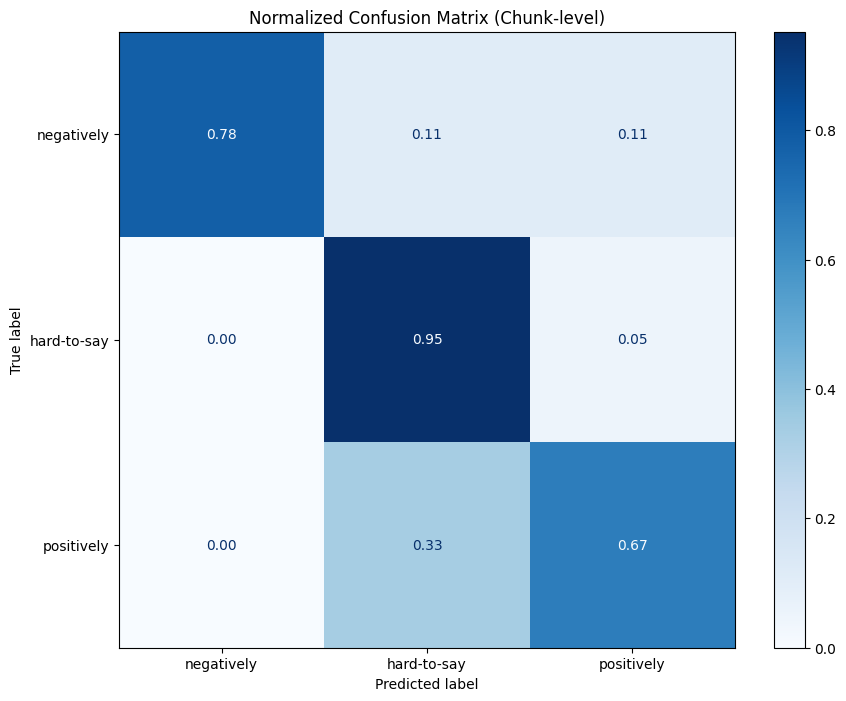

In [53]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_high_tech chunks with the fine tuned model

In [54]:
print(df_traditional.shape)

(1448, 8)


In [55]:
from datasets import Dataset

df_traditional_pred = (
    df_traditional[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

ai_stock_pred_dataset = Dataset.from_pandas(df_traditional_pred, preserve_index=False)
ai_stock_pred_dataset = ai_stock_pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/1448 [00:00<?, ? examples/s]

In [56]:
pred_output = trainer.predict(ai_stock_pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_traditional_pred["pred_label_id"] = pred_ids
df_traditional_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_traditional_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_traditional_pred[f"prob_{label_name}"] = probs[:, i]

print(df_traditional_pred.shape)
df_traditional_pred.head()

(1448, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,810_0_0_0_0,https://timesofindia.indiatimes.com/business/i...,2025-10-07,'Mine baby mine': Trump approves Alaska mining...,7,'Mine baby mine': Trump approves Alaska mining...,hard-to-say,0.889170,0.021893,0.889170,0.088936
1,1573_0_0_0_0,https://www.ruetir.com/2023/10/10-technologies...,2023-10-17,10 Technologies Made in Israel that We Unknowi...,4,10 Technologies Made in Israel that We Unknowi...,hard-to-say,0.855277,0.016741,0.855277,0.127982
2,1573_0_0_0_1,https://www.ruetir.com/2023/10/10-technologies...,2023-10-17,10 Technologies Made in Israel that We Unknowi...,4,Security Technology Israel has achieved intern...,hard-to-say,0.845346,0.042708,0.845346,0.111946
3,1573_0_0_0_2,https://www.ruetir.com/2023/10/10-technologies...,2023-10-17,10 Technologies Made in Israel that We Unknowi...,4,5. Medical Technology Israel has advanced medi...,hard-to-say,0.582704,0.115472,0.582704,0.301824
4,1607_1_0_0_0,https://tribuneonlineng.com/10-countries-using...,2025-09-22,10 countries using AI to boost food security –...,4,"7. Senegal\nSenegal is using AI, satellite ima...",hard-to-say,0.539349,0.201885,0.539349,0.258767


/tmp/ipykernel_31730/3973042337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


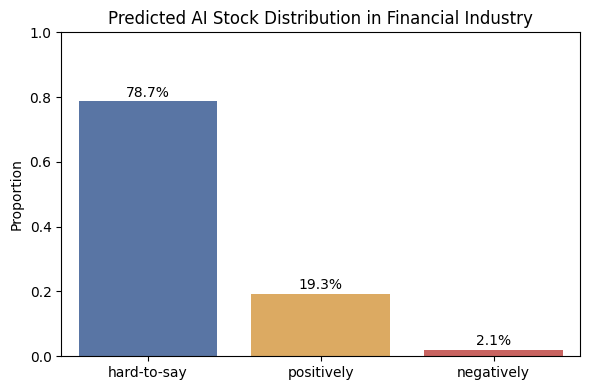

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

dist = df_traditional_pred["pred_label"].value_counts(normalize=True)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Stock Distribution in Traditional Production Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [58]:
df_traditional_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [5]:
df_high_tech_pred = pd.read_parquet(f"{model_dir}/phyprod_hightech_classifier_predictions.parquet")
print(df_high_tech_pred.shape)
df_high_tech_pred.head(2)

(5784, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,46_0_0_0_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"""Export control was a failure."" Nvidia CEO Jen...",negatively,0.558900,0.55890,0.167321,0.273778
1,46_1_0_9_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"So there are lots of startups in China, GPU co...",positively,0.585994,0.08817,0.325836,0.585994


#### Hightech - Positive impact

In [7]:
df_high_tech_ner_sample = df_high_tech_pred.loc[df_high_tech_pred['pred_label'] == 'positively'].sample(800, random_state=38).reset_index(drop=True)

In [9]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [10]:
entity_system_msg = """\
You are an information extraction system for news articles about high-tech production industries.

The user will provide a text block from a news article.
Your task is to extract only the following:

1. organizations or companies in the high-tech production ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or positive impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named companies, manufacturers, suppliers, chipmakers, hardware firms, automakers,
robotics companies, cloud or infrastructure firms, or other organizations explicitly stated in the text
that are relevant to the high-tech production ecosystem.

Examples:
- Nvidia
- AMD
- Intel
- TSMC
- Samsung Electronics
- Micron
- Qualcomm
- Huawei
- Tesla
- ASML
- Foxconn
- SK Hynix

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies, capabilities, hardware categories, or positive business/industry impact mechanisms
explicitly mentioned in the text.

This includes but is not limited to:
- artificial intelligence
- generative AI
- large language models
- machine learning
- AI chips
- GPUs
- NPUs
- processors
- semiconductors
- advanced packaging
- data-center hardware
- robotics
- autonomous driving systems
- smart manufacturing
- industrial automation
- computer vision
- yield improvement
- capacity expansion
- productivity improvement
- efficiency gains
- revenue growth
- demand growth

## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the manufacturer”, “the industry”, or “chipmakers”
  unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [11]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [12]:
hightech_ner_pos = []

for idx, row in df_high_tech_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    hightech_ner_pos.append(result)
    
df_hightech_ner_pos_result = pd.DataFrame(hightech_ner_pos)

[Row 290] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}
[Row 654] Failed: Unterminated string starting at: line 3 column 8222 (char 8381)


In [13]:
df_hightech_ner_pos_result.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/df_hightech_ner_pos_result.parquet", index=False)

##### Organization 

In [16]:
df_high_tech_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Phy_Prod_specific/df_hightech_ner_pos_result.parquet")

In [17]:
df_posorg_long = (
    df_high_tech_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(958, 2)
(266, 2)


,entity_raw,raw_count
0,Nvidia,226
1,Intel,124
2,Tesla,112
3,TSMC,112
4,Google,108
...,...,...
261,Volvo Car Corporation,2
262,Wall Street Journal,2
263,Walmart,2
264,WebProNews,2


In [18]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

'- (Nvidia, 226)\n- (Intel, 124)\n- (Tesla, 112)\n- (TSMC, 112)\n- (Google, 108)\n- (Samsung, 87)\n- (Apple, 86)\n- (AMD, 76)\n- (Microsoft, 53)\n- (SK Hynix, 50)\n- (Qualcomm, 46)\n- (OpenAI, 44)\n- (Samsung Electronics, 39)\n- (Huawei, 33)\n- (Broadcom, 27)\n- (NVIDIA, 26)\n- (Mercedes-Benz, 26)\n- (Taiwan Semiconductor Manufacturing, 25)\n- (ASML, 19)\n- (Alphabet, 19)\n- (Micron, 19)\n- (Zoom, 17)\n- (Advanced Micro Devices, 17)\n- (Volkswagen, 17)\n- (Taiwan Semiconductor, 16)\n- (Micron Technology, 16)\n- (Adobe, 15)\n- (SK hynix, 15)\n- (Amazon, 15)\n- (TrendForce, 14)\n- (Baidu, 13)\n- (Habana Labs, 13)\n- (Alibaba, 13)\n- (DeepSeek, 11)\n- (BMW, 11)\n- (BYD, 10)\n- (Morgan Stanley, 10)\n- (Reuters, 10)\n- (Lenovo, 9)\n- (AWS, 9)\n- (Cerence, 9)\n- (CNBC, 9)\n- (Boston Dynamics, 8)\n- (Stellantis, 8)\n- (Honda, 8)\n- (Tencent, 8)\n- (Huawei Technologies, 8)\n- (ByteDance, 8)\n- (Hyundai, 8)\n- (HP, 7)\n- (IDC, 7)\n- (Alphabet Inc., 7)\n- (Meta Platforms, 7)\n- (Meta, 7)\n- (Del

In [19]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from hightech_production-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - hightech_production_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 hightech_production companies
   - Top 10 AI companies

Rules:
- Be conservative when merging.
- Do not merge different companies.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "hightech_production_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "hightech_production_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["hightech_production_top10", "ai_top10"],
    "additionalProperties": False
}

In [20]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [21]:
industry_company_top10_pos = pd.DataFrame(result_posorg["hightech_production_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Hightech Production Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Hightech Production Top 10


,canonical_name,total_count,source_raw_names
0,Nvidia,256,"[Nvidia, NVIDIA, Nvidia Corp., NVIDIA Corporat..."
1,Intel,130,"[Intel, Intel Corporation]"
2,TSMC,167,"[TSMC, Taiwan Semiconductor Manufacturing, Tai..."
3,Samsung,131,"[Samsung, Samsung Electronics, Samsung Electro..."
4,AMD,95,"[AMD, Advanced Micro Devices, Advanced Micro D..."
5,SK Hynix,70,"[SK Hynix, SK hynix, SK Hynix Inc.]"
6,Micron,40,"[Micron, Micron Technology, Micron Technology ..."
7,ASML,21,"[ASML, ASML Holding]"
8,Qualcomm,50,"[Qualcomm, Qualcomm Inc.]"
9,Broadcom,27,[Broadcom]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,44,[OpenAI]
1,Google,110,"[Google, Google Cloud]"
2,Microsoft,58,"[Microsoft, Microsoft Corp., Microsoft Corpora..."
3,Amazon,20,"[Amazon, Amazon Web Services]"
4,Meta,15,"[Meta Platforms, Meta, Meta Platforms Inc.]"
5,Alphabet,26,"[Alphabet, Alphabet Inc.]"
6,Baidu,13,[Baidu]
7,Alibaba,16,"[Alibaba, Alibaba Group]"
8,Tencent,11,"[Tencent, Tencent Holdings Ltd., Tencent Holdi..."
9,IBM,7,"[IBM, IBM Corporation]"


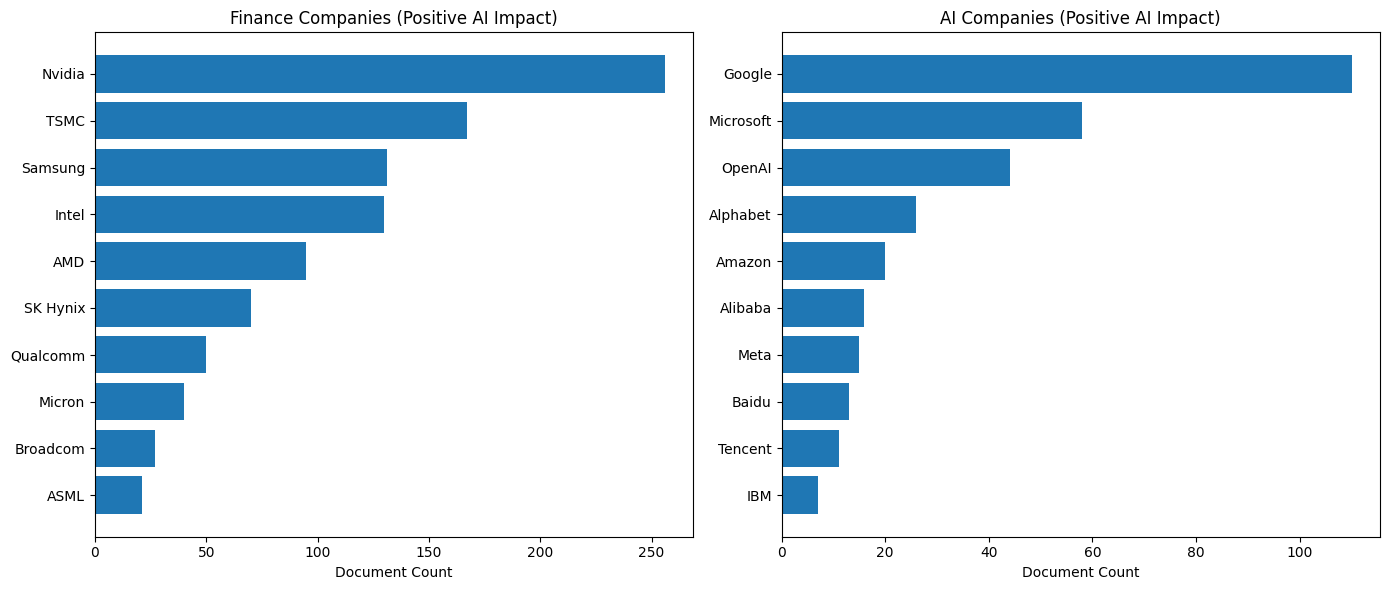

In [22]:
import matplotlib.pyplot as plt
import numpy as np

hightech_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Hightech Production ---
axes[0].barh(hightech_df["canonical_name"], hightech_df["total_count"])
axes[0].set_title("Hightech Production Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [23]:
df_posmech_long = (
    df_high_tech_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(3093, 2)
(576, 2)


,entity_raw,raw_count
0,artificial intelligence,332
1,AI,160
2,AI chips,130
3,demand growth,118
4,generative AI,94
...,...,...
571,training AI models,2
572,training and inference systems,2
573,FSD Beta,2
574,Driver Monitoring System,2


In [27]:
posmech_candidate_pairs = list(
    posmech_candidates.head(400)[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

"- (artificial intelligence, 332)\n- (AI, 160)\n- (AI chips, 130)\n- (demand growth, 118)\n- (generative AI, 94)\n- (revenue growth, 90)\n- (GPUs, 44)\n- (AI models, 44)\n- (machine learning, 39)\n- (robotics, 36)\n- (autonomous driving, 34)\n- (capacity expansion, 30)\n- (processors, 30)\n- (efficiency, 29)\n- (AI applications, 28)\n- (AI chip, 27)\n- (autonomous vehicles, 26)\n- (AI infrastructure, 26)\n- (ChatGPT, 24)\n- (performance, 24)\n- (large language models, 23)\n- (AI workloads, 22)\n- (AI demand, 22)\n- (AI accelerators, 22)\n- (AI features, 22)\n- (humanoid robot, 21)\n- (AI training, 20)\n- (efficiency gains, 20)\n- (memory chips, 20)\n- (computing power, 20)\n- (data centers, 20)\n- (AI capabilities, 19)\n- (power efficiency, 19)\n- (DRAM, 19)\n- (GPU, 19)\n- (semiconductors, 18)\n- (NPU, 17)\n- (chips, 17)\n- (AI hardware, 17)\n- (NPUs, 16)\n- (AI performance, 16)\n- (HBM3E, 16)\n- (HBM, 16)\n- (AI chatbot, 15)\n- (inferencing, 15)\n- (AI boom, 15)\n- (computer vision, 

In [28]:
posmech_top_system_msg = """\
You are an AI technology and business mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from hightech_production-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_business_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI business mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.


### ai_business_mechanism
Business applications, operational impacts, or use-case mechanisms of AI.


### other
Anything vague, unclear, or not clearly technology or mechanism.

Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [29]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [30]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,AI chips,130,"[AI chips, AI chip, artificial intelligence ch..."
1,generative AI,102,"[generative AI, generative artificial intellig..."
2,GPUs,77,"[GPUs, GPU, graphics processing units, graphic..."
3,AI models,72,"[AI models, AI model, large language models, l..."
4,machine learning,52,"[machine learning, Machine Learning, machine l..."
5,AI accelerators,50,"[AI accelerators, AI accelerator, accelerators]"
6,HBM,49,"[HBM, HBM3E, HBM3, high-bandwidth memory, HBM ..."
7,AI processors,48,"[processors, AI processors, AI processor, AI c..."
8,NPUs,45,"[NPU, NPUs, neural processing unit, Neural Pro..."
9,autonomous driving,44,"[autonomous driving, autonomous vehicles, auto..."


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,demand growth,118,"[demand growth, AI demand, AI-related demand, ..."
1,revenue growth,90,"[revenue growth, revenue, AI-related revenue, ..."
2,capacity expansion,30,"[capacity expansion, expansion, production cap..."
3,efficiency,29,"[efficiency, efficiency gains, power efficienc..."
4,AI applications,28,"[AI applications, AI features, AI-powered feat..."
5,AI infrastructure,26,"[AI infrastructure, AI servers, AI data center..."
6,performance,24,"[performance, AI performance, improved graphic..."
7,AI workloads,22,"[AI workloads, AI training, training, inferenc..."
8,AI capabilities,19,"[AI capabilities, AI technology, AI technologi..."
9,robotics,36,"[robotics, humanoid robot, humanoid robots, ro..."


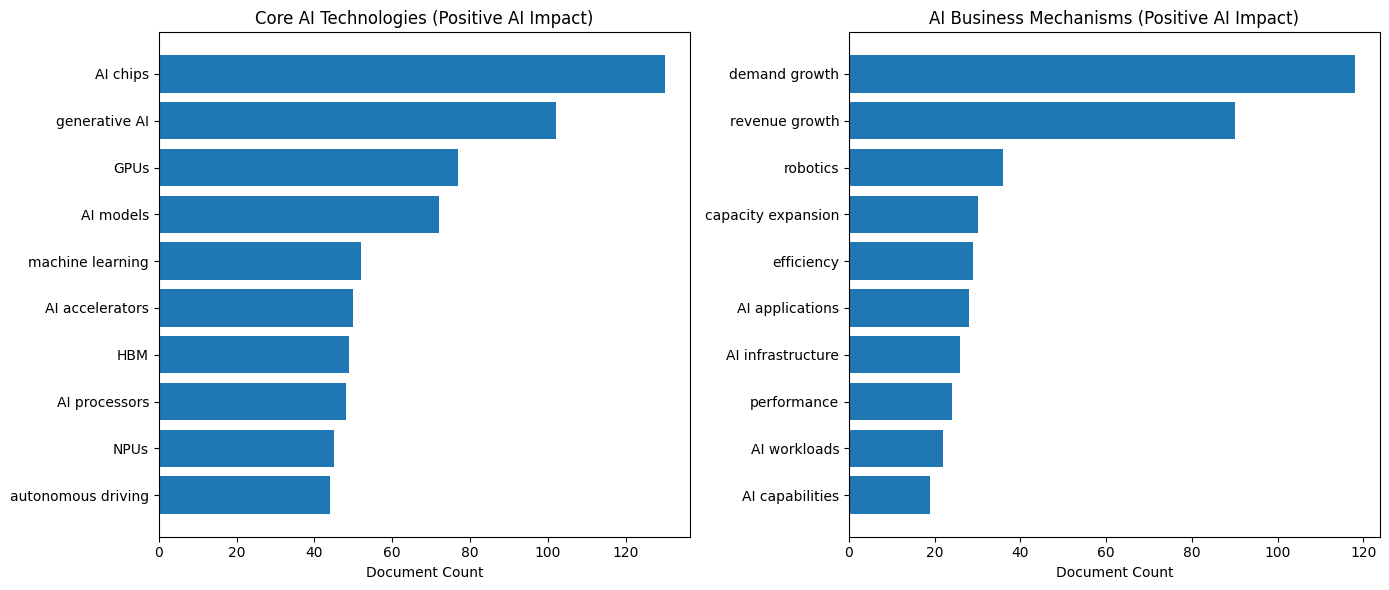

In [31]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Hightech - Negative impact

In [33]:
df_hightech_negative_impact_ner_sample = df_high_tech_pred.loc[df_high_tech_pred['pred_label'] == 'negatively'].sample(400, random_state=43).reset_index(drop=True)
print(len(df_hightech_negative_impact_ner_sample))

400


In [34]:
neg_entity_system_msg = """\
You are an information extraction system for high-tech production related news articles.

The user will provide a text block from a high-tech production related article.
This dataset focuses specifically on NEGATIVE impacts of AI or AI-related technologies.

Your task is to extract only the following:

1. organizations or companies in the high-tech production ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named companies, manufacturers, suppliers, chipmakers, hardware firms, automakers,
robotics companies, semiconductor firms, or infrastructure firms explicitly mentioned in the text
that are part of the high-tech production ecosystem.

Examples include:
- Nvidia
- AMD
- Intel
- TSMC
- Samsung Electronics
- Micron
- Qualcomm
- Huawei
- Tesla
- ASML
- Foxconn
- SK Hynix
- Broadcom
- Apple


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract AI-related technologies, hardware categories, or NEGATIVE industry impact mechanisms
explicitly mentioned in the text.

This includes but is not limited to:

AI technologies / infrastructure:
- artificial intelligence
- generative AI
- machine learning
- large language models
- AI chips
- GPUs
- NPUs
- semiconductors
- advanced chips
- data-center hardware
- robotics
- autonomous driving systems
- industrial automation

Negative impact mechanisms may include:
- export restrictions
- export controls
- sanctions
- supply chain disruption
- geopolitical restrictions
- regulatory pressure
- production slowdown
- manufacturing delays
- cost increases
- demand uncertainty
- market share loss
- competitive pressure
- technological disadvantage
- operational disruption
- investment pullback
- layoffs
- factory shutdowns


## Directions

- Focus especially on negative AI-related mechanisms, risks, harms, and downsides.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the organization”, “the firm”, or “chipmakers”
  unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [35]:
train_hightech_negative_impact_ner = []

for idx, row in df_hightech_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_hightech_negative_impact_ner.append(result)
    
df_hightech_negative_impact_ner_result = pd.DataFrame(train_hightech_negative_impact_ner)

[Row 235] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


In [36]:
df_hightech_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/hightech_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [37]:
df_negorg_long = (
    df_hightech_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(322, 2)
(117, 2)


,entity_raw,raw_count
0,Nvidia,296
1,Huawei,88
2,AMD,83
3,Intel,40
4,TSMC,33
...,...,...
112,Trump administration,2
113,Tsinghua University,2
114,Promsvyazbank,2
115,Shenzhen University,2


In [38]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (Nvidia, 296)\n- (Huawei, 88)\n- (AMD, 83)\n- (Intel, 40)\n- (TSMC, 33)\n- (Alibaba, 27)\n- (ByteDance, 23)\n- (Advanced Micro Devices, 23)\n- (Commerce Department, 23)\n- (Microsoft, 20)\n- (DeepSeek, 20)\n- (Tencent, 19)\n- (NVIDIA, 19)\n- (Google, 18)\n- (OpenAI, 17)\n- (China, 15)\n- (SMIC, 15)\n- (ASML, 14)\n- (Baidu, 14)\n- (Apple, 13)\n- (Micron, 10)\n- (Amazon, 10)\n- (Cambricon, 9)\n- (Biden administration, 9)\n- (Huawei Technologies, 9)\n- (China Council for Promotion of International Trade, 9)\n- (Samsung, 8)\n- (Reuters, 8)\n- (Samsung Electronics, 7)\n- (White House, 7)\n- (SK Hynix, 7)\n- (Semiconductor Industry Association, 7)\n- (Anthropic, 7)\n- (Tesla, 7)\n- (YMTC, 6)\n- (CXMT, 6)\n- (Meta, 6)\n- (Qualcomm, 6)\n- (Tencent Holdings, 6)\n- (Alibaba Group, 5)\n- (Advanced Micro Devices Inc, 5)\n- (U.S. Department of Commerce, 5)\n- (Oracle, 5)\n- (CNBC, 5)\n- (Super Micro Computer, 5)\n- (U.S. Commerce Department, 5)\n- (AWS, 5)\n- (ALX Solutions, 4)\n- (Bloomberg, 4)

In [39]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [42]:
industry_company_top10_neg = pd.DataFrame(result_negorg["hightech_production_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Hightech Production Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Hightech Production Top 10


,canonical_name,total_count,source_raw_names
0,Nvidia,319,"[Nvidia, NVIDIA, Nvidia Corp.]"
1,Huawei,101,"[Huawei, Huawei Technologies, Huawei Technolog..."
2,AMD,111,"[AMD, Advanced Micro Devices, Advanced Micro D..."
3,Intel,40,[Intel]
4,TSMC,39,"[TSMC, Taiwan Semiconductor Manufacturing Co, ..."
5,SMIC,17,"[SMIC, Semiconductor Manufacturing Internation..."
6,ASML,14,[ASML]
7,Samsung,15,"[Samsung, Samsung Electronics]"
8,SK Hynix,9,"[SK Hynix, SK hynix]"
9,Micron,10,[Micron]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,17,[OpenAI]
1,DeepSeek,22,"[DeepSeek, Deepseek]"
2,Anthropic,7,[Anthropic]
3,Google,18,[Google]
4,Microsoft,20,[Microsoft]
5,Meta,6,[Meta]
6,Amazon,12,"[Amazon, Amazon.com Inc, Amazon.com, Amazon We..."
7,Alibaba,32,"[Alibaba, Alibaba Group, Alibaba Group Holding..."
8,ByteDance,23,[ByteDance]
9,Tencent,25,"[Tencent, Tencent Holdings]"


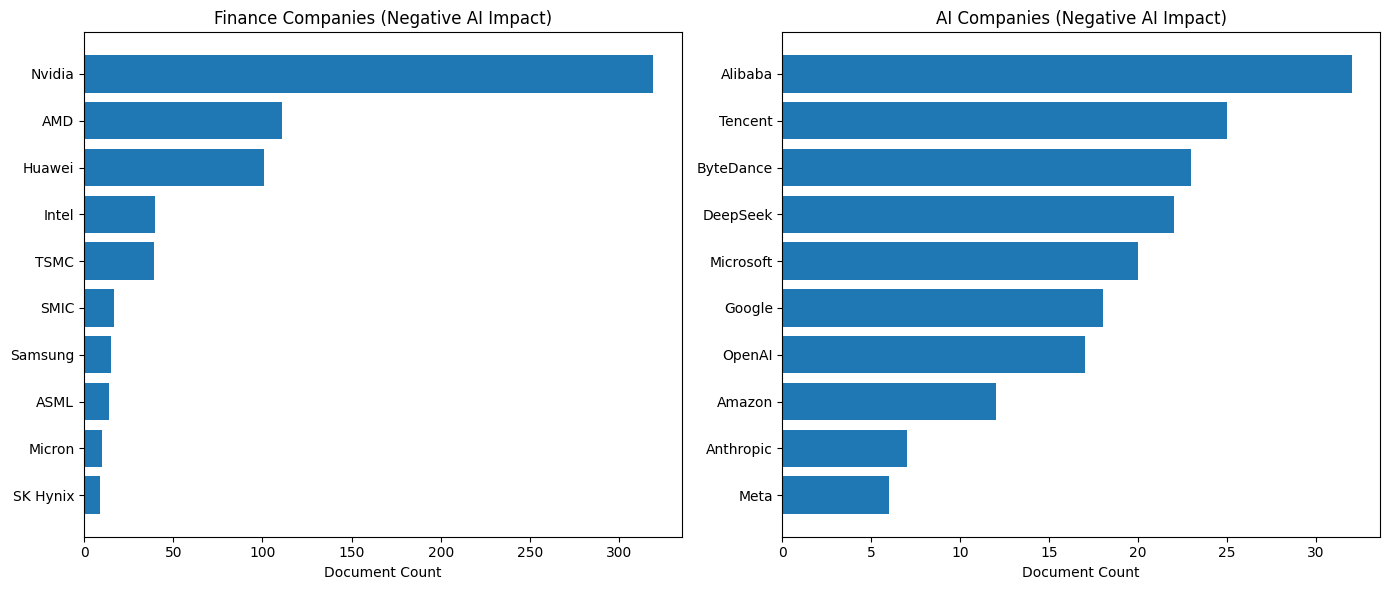

In [43]:
import matplotlib.pyplot as plt
import numpy as np

hightech_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Hightech Production ---
axes[0].barh(hightech_df["canonical_name"], hightech_df["total_count"])
axes[0].set_title("Hightech Production Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [44]:
df_ai_mech_long_neg = (
    df_hightech_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(910, 2)
(202, 2)


,entity_raw,raw_count
0,export restrictions,291
1,AI chips,289
2,export controls,221
3,supply chain disruption,175
4,technological disadvantage,150
...,...,...
197,advanced AI processors,2
198,artificial-intelligence chip,2
199,advanced packaging,2
200,A800 chips,2


In [45]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

'- (export restrictions, 291)\n- (AI chips, 289)\n- (export controls, 221)\n- (supply chain disruption, 175)\n- (technological disadvantage, 150)\n- (artificial intelligence, 143)\n- (competitive pressure, 126)\n- (geopolitical restrictions, 124)\n- (regulatory pressure, 116)\n- (operational disruption, 83)\n- (GPUs, 72)\n- (market share loss, 67)\n- (sanctions, 62)\n- (manufacturing delays, 58)\n- (production slowdown, 54)\n- (advanced chips, 43)\n- (investment pullback, 34)\n- (cost increases, 28)\n- (semiconductors, 25)\n- (demand uncertainty, 25)\n- (artificial intelligence chips, 22)\n- (layoffs, 21)\n- (factory shutdowns, 19)\n- (AI chip, 17)\n- (national security concerns, 17)\n- (national security, 17)\n- (generative AI, 16)\n- (advanced AI chips, 13)\n- (machine learning, 12)\n- (large language models, 11)\n- (AI models, 11)\n- (export ban, 9)\n- (smuggling, 9)\n- (advanced semiconductors, 9)\n- (ban, 9)\n- (restrictions, 9)\n- (export bans, 9)\n- (AI processors, 8)\n- (tariff

In [46]:
neg_mech_top_system_msg = """\
You are an AI technology and industry impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from high-tech production industry news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_business_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI business negative impact mechanisms


Definitions:


### core_ai_technology

Fundamental AI technologies, hardware, or infrastructure used in the high-tech production ecosystem.

Examples include:
- generative AI
- large language models
- machine learning
- deep learning
- neural networks
- computer vision
- natural language processing
- AI chips
- GPUs
- NPUs
- semiconductors
- data-center hardware
- robotics
- autonomous driving systems
- industrial AI


### ai_business_mechanism

Negative business or industry impact mechanisms caused by AI technologies
in the high-tech production ecosystem.

These may include geopolitical, regulatory, operational, or competitive pressures.

Examples include:

Geopolitical / regulatory constraints
- export controls
- export restrictions
- sanctions
- technology bans
- regulatory restrictions
- national security restrictions

Supply chain and production risks
- semiconductor supply chain disruption
- chip shortages
- manufacturing delays
- production bottlenecks
- fabrication constraints

Market and competitive pressure
- loss of market share
- competitive pressure
- technological disadvantage
- demand volatility
- pricing pressure

Operational risks
- production disruption
- cost escalation
- investment pullback
- capacity constraints
- supply instability


### other

Anything vague, unclear, or not clearly a technology or a business mechanism.


Rules:

- Merge raw names only when they clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and industry-standard.
- Use counts exactly as provided.
- Preserve the most widely recognizable terminology when selecting canonical names.


Return valid JSON only.
"""

In [47]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [48]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,AI chips,376,"[AI chips, AI chip, artificial intelligence ch..."
1,GPUs,83,"[GPUs, AI GPUs, GPU, graphics processing units..."
2,semiconductors,41,"[semiconductors, advanced semiconductors, adva..."
3,generative AI,18,"[generative AI, generative AI models]"
4,machine learning,12,[machine learning]
5,large language models,13,"[large language models, AI models, LLMs]"
6,artificial intelligence,143,"[artificial intelligence, AI, AI technologies,..."
7,natural language processing,3,[natural language processing]
8,robotics,2,[robotics]
9,computer vision,5,[image recognition]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,export restrictions,566,"[export restrictions, export controls, export ..."
1,supply chain disruption,180,"[supply chain disruption, supply chains, short..."
2,technological disadvantage,150,[technological disadvantage]
3,competitive pressure,128,"[competitive pressure, competitive position ma..."
4,geopolitical restrictions,124,[geopolitical restrictions]
5,regulatory pressure,118,"[regulatory pressure, regulatory requirements,..."
6,operational disruption,83,[operational disruption]
7,market share loss,69,"[market share loss, lost sales, revenue loss, ..."
8,sanctions,62,"[sanctions, U.S. sanctions]"
9,manufacturing delays,58,[manufacturing delays]


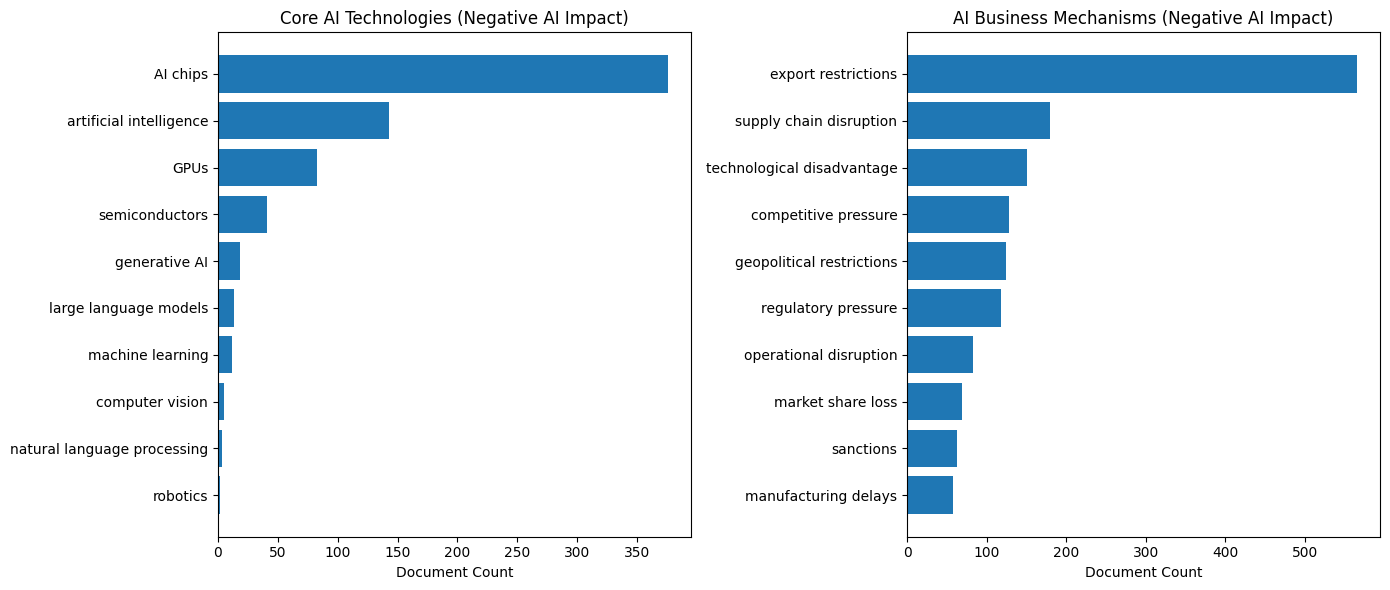

In [49]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Tradition - Positive impact

In [53]:
df_traditional_pred = pd.read_parquet(f"{model_dir}/phyprod_tradition_classifier_predictions.parquet")
print(df_traditional_pred.shape)

(1448, 11)


In [58]:
df_traditional_ner_pos = df_traditional_pred.loc[df_traditional_pred['pred_label'] == 'positively'].reset_index(drop=True)
print(df_traditional_ner_pos.shape)

(279, 11)


In [60]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [61]:
pos_entity_system_msg = """\
You are an information extraction system for traditional physical production related news articles.

The user will provide a text block from a traditional production related article.
Your task is to extract only the following:

1. organizations or companies in the traditional production ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or positive impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named companies, producers, manufacturers, agricultural firms, drilling or mining companies,
industrial materials firms, food producers, chemicals companies, logistics firms, or other organizations
explicitly stated in the text that are relevant to the traditional production ecosystem.


Examples:
- Deere & Company
- Cargill
- Archer Daniels Midland
- Bunge
- Tyson Foods
- Nestle
- ExxonMobil
- Chevron
- Rio Tinto
- BHP
- Caterpillar
- Dow
- BASF

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies, production use cases, or positive impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:
- artificial intelligence
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- robotics
- industrial automation
- smart manufacturing
- quality inspection
- defect detection
- yield improvement
- production optimization
- cost reduction
- supply-chain optimization
- logistics optimization
- resource allocation
- inventory optimization
- crop monitoring
- precision agriculture
- demand forecasting
- energy efficiency


## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the producer”, “the manufacturer”, “farmers”,
  “miners”, or “the industry” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""
entity_user_template = """\
Title: {title}

Text:
{text}
"""
entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [63]:
tradition_ner_pos = []

for idx, row in df_traditional_ner_pos.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=pos_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    tradition_ner_pos.append(result)
    
df_tradition_ner_pos_result = pd.DataFrame(tradition_ner_pos)

In [64]:
df_tradition_ner_pos_result.to_parquet(f"{DATA_DIR}/Phy_Prod_specific/df_tradition_ner_pos_result.parquet", index=False)

##### Organization

In [65]:
df_posorg_long = (
    df_tradition_ner_pos_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(648, 2)
(167, 2)


,entity_raw,raw_count
0,Deere & Company,10
1,IBM Corporation,7
2,Cropin,7
3,FarmERP,6
4,Vantage Market Research,6
...,...,...
162,Datacentrix,2
163,"Walter Scott, Jr. College of Engineering",2
164,Warner College of Natural Resources,2
165,ABx Group,2


In [66]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

'- (Deere & Company, 10)\n- (IBM Corporation, 7)\n- (Cropin, 7)\n- (FarmERP, 6)\n- (Vantage Market Research, 6)\n- (Microsoft Corporation, 5)\n- (Syngenta, 5)\n- (Case IH, 5)\n- (Microsoft, 5)\n- (Canadian Gold Corp., 5)\n- (New Holland, 4)\n- (Roscan Gold, 4)\n- (Google, 4)\n- (Farmers Edge Inc., 4)\n- (IBM, 4)\n- (Bayer AG, 4)\n- (Bem Agro, 4)\n- (Source.ag, 4)\n- (AGCO Corporation, 4)\n- (SK networks, 4)\n- (Granular Inc., 4)\n- (Ecorobotix, 4)\n- (Heifer International, 3)\n- (The Climate Corporation, 3)\n- (ResearchAndMarkets.com, 3)\n- (B2Gold Corp., 3)\n- (Otipy, 3)\n- (John Deere, 3)\n- (CNH Industrial, 3)\n- (Innovate UK, 3)\n- (NASSCOM, 3)\n- (Ceres Imaging, 3)\n- (Gardin, 3)\n- (Grownetics Inc., 3)\n- (FruitPunch AI, 3)\n- (Google LLC, 3)\n- (Agnico Eagle, 3)\n- (Tullamore Farm, 3)\n- (Ridder, 3)\n- (Endurance Gold Corporation, 3)\n- (DJI, 3)\n- (CSIRO, 3)\n- (Raven Industries Inc., 3)\n- (Prime, 3)\n- (Protein Industries Canada, 3)\n- (Sayona Mining Ltd, 2)\n- (Satsure, 2)\n

In [69]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from traditional production industry AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - traditional_production_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 traditional production companies
   - Top 10 AI companies


Rules:
- Be conservative when merging.
- Do not merge different companies.
- Use the most widely recognized company name as the canonical_name.
- traditional_production_company should be companies primarily producing physical goods or operating industrial production systems.
- ai_company should be companies primarily focused on AI technologies or AI infrastructure.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).
- Use counts exactly as given.

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "traditional_production_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "traditional_production_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["traditional_production_top10", "ai_top10"],
    "additionalProperties": False
}

In [70]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [71]:
industry_company_top10_pos = pd.DataFrame(result_posorg["traditional_production_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Traditional Production Industry Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Traditional Production Industry Top 10


,canonical_name,total_count,source_raw_names
0,John Deere,15,"[Deere & Company, John Deere, John Deere & Com..."
1,CNH Industrial,10,"[CNH Industrial, CNH, CNH Industrial N.V.]"
2,Case IH,7,"[Case IH, Case IH Agriculture, CASE]"
3,New Holland,6,"[New Holland, New Holland Construction Equipment]"
4,AGCO Corporation,4,[AGCO Corporation]
5,Syngenta,5,[Syngenta]
6,Bayer,8,"[Bayer AG, Bayer CropScience AG, Bayer]"
7,Trimble Inc.,2,[Trimble Inc.]
8,DJI,3,[DJI]
9,Raven Industries Inc.,5,"[Raven Industries Inc., Raven]"


AI Top 10


,canonical_name,total_count,source_raw_names
0,Microsoft,10,"[Microsoft Corporation, Microsoft]"
1,IBM,11,"[IBM Corporation, IBM]"
2,Google,7,"[Google, Google LLC]"
3,Cropin,11,"[Cropin, Cropin Technology, Cropin Technology ..."
4,FarmERP,6,[FarmERP]
5,The Climate Corporation,5,"[The Climate Corporation, Climate LLC]"
6,Farmers Edge Inc.,4,[Farmers Edge Inc.]
7,Granular Inc.,6,"[Granular Inc., Granular AG]"
8,Source.ag,4,[Source.ag]
9,Ceres Imaging,3,[Ceres Imaging]


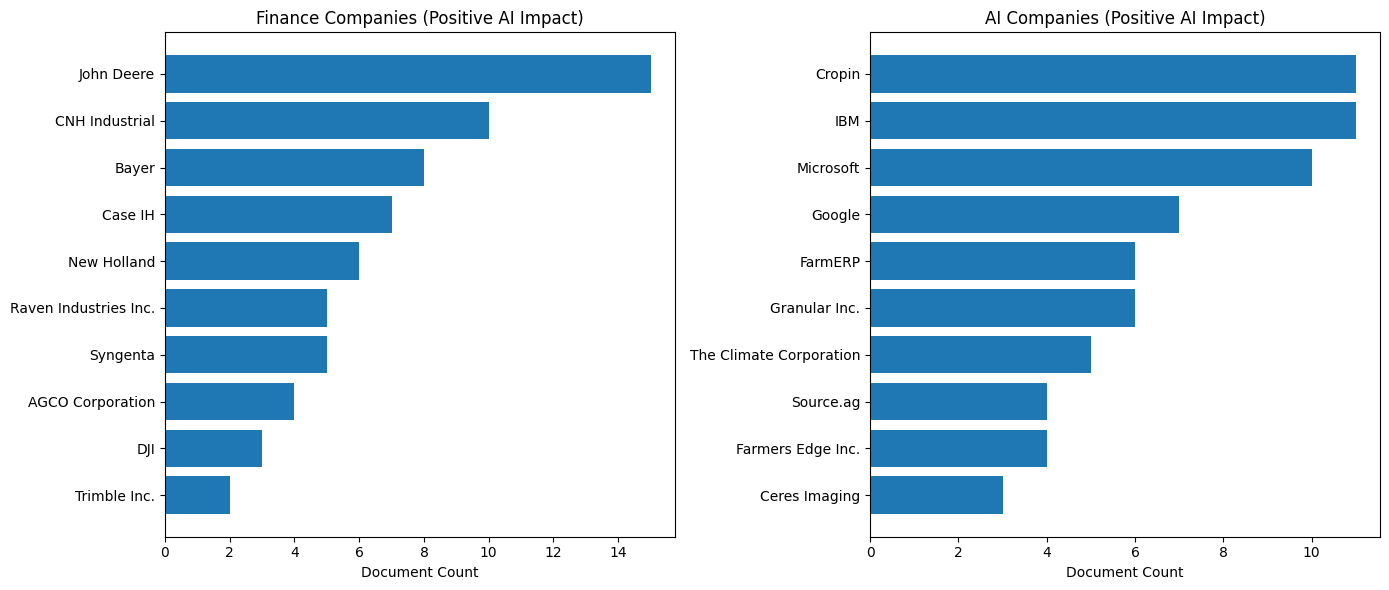

In [72]:
import matplotlib.pyplot as plt
import numpy as np

traditional_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Traditional Production ---
axes[0].barh(traditional_df["canonical_name"], traditional_df["total_count"])
axes[0].set_title("Traditional Production Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Tech and Mech

In [74]:
df_posmech_long = (
    df_tradition_ner_pos_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(958, 2)
(178, 2)


,entity_raw,raw_count
0,artificial intelligence,120
1,machine learning,58
2,precision agriculture,28
3,predictive analytics,25
4,computer vision,25
...,...,...
173,Precision Agriculture,2
174,weed mapping,2
175,weed detection,2
176,AI applications,2


In [75]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (artificial intelligence, 120)\n- (machine learning, 58)\n- (precision agriculture, 28)\n- (predictive analytics, 25)\n- (computer vision, 25)\n- (AI, 23)\n- (precision farming, 21)\n- (crop monitoring, 18)\n- (generative AI, 16)\n- (production optimization, 14)\n- (yield improvement, 13)\n- (automation, 10)\n- (cost reduction, 10)\n- (deep learning, 9)\n- (data analytics, 7)\n- (robotics, 7)\n- (real-time monitoring, 7)\n- (drone analytics, 7)\n- (pest detection, 7)\n- (predictive intelligence, 7)\n- (livestock monitoring, 6)\n- (smart farming, 6)\n- (resource allocation, 6)\n- (Artificial Intelligence, 6)\n- (supply-chain optimization, 5)\n- (AI models, 5)\n- (AI technology, 5)\n- (disease detection, 5)\n- (decision-making, 5)\n- (crop health monitoring, 5)\n- (AI algorithms, 5)\n- (yield prediction, 5)\n- (yield estimation, 5)\n- (digital agriculture, 4)\n- (data-driven agriculture, 4)\n- (quality inspection, 4)\n- (AI tools, 4)\n- (demand forecasting, 4)\n- (Artificial Intellige

In [76]:
posmech_top_system_msg = """\
You are an AI technology and traditional production impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from traditional production industry AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_traditional_production_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI traditional production mechanisms


Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples include:
- generative AI
- large language models
- machine learning
- computer vision
- predictive analytics
- robotics
- industrial automation


### ai_traditional_production_mechanism
Operational, production, logistics, agricultural, extraction, or manufacturing mechanisms
through which AI positively affects traditional physical production industries.

Examples include:
- predictive maintenance
- precision agriculture
- crop monitoring
- yield improvement
- supply-chain optimization
- inventory optimization
- demand forecasting
- downtime reduction
- operational efficiency
- productivity improvement
- resource allocation
- energy efficiency


### other
Anything vague, unclear, or not clearly an AI technology or traditional production mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_traditional_production_mechanism when the traditional production context is clear.
- machine learning, deep learning, and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [77]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [78]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,artificial intelligence,157,"[artificial intelligence, AI, Artificial Intel..."
1,machine learning,72,"[machine learning, deep learning, ML, deep lea..."
2,generative AI,16,[generative AI]
3,computer vision,25,[computer vision]
4,predictive analytics,32,"[predictive analytics, predictive intelligence..."
5,robotics,12,"[robotics, robots, agriculture robots, agricul..."
6,automation,12,"[automation, automation technologies, autonomo..."
7,data analytics,12,"[data analytics, advanced analytics, big data ..."
8,large language models,2,[large language models]
9,natural language processing,2,[natural language processing]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,precision agriculture,59,"[precision agriculture, precision farming, sma..."
1,crop monitoring,30,"[crop monitoring, crop health monitoring, crop..."
2,yield improvement,29,"[yield improvement, yield prediction, yield es..."
3,production optimization,14,[production optimization]
4,supply-chain optimization,7,"[supply-chain optimization, supply chain optim..."
5,resource allocation,6,"[resource allocation, allocating resources]"
6,demand forecasting,4,"[demand forecasting, forecasting]"
7,energy efficiency,4,[energy efficiency]
8,operational efficiency,2,[operational efficiency]
9,inventory optimization,2,[inventory optimization]


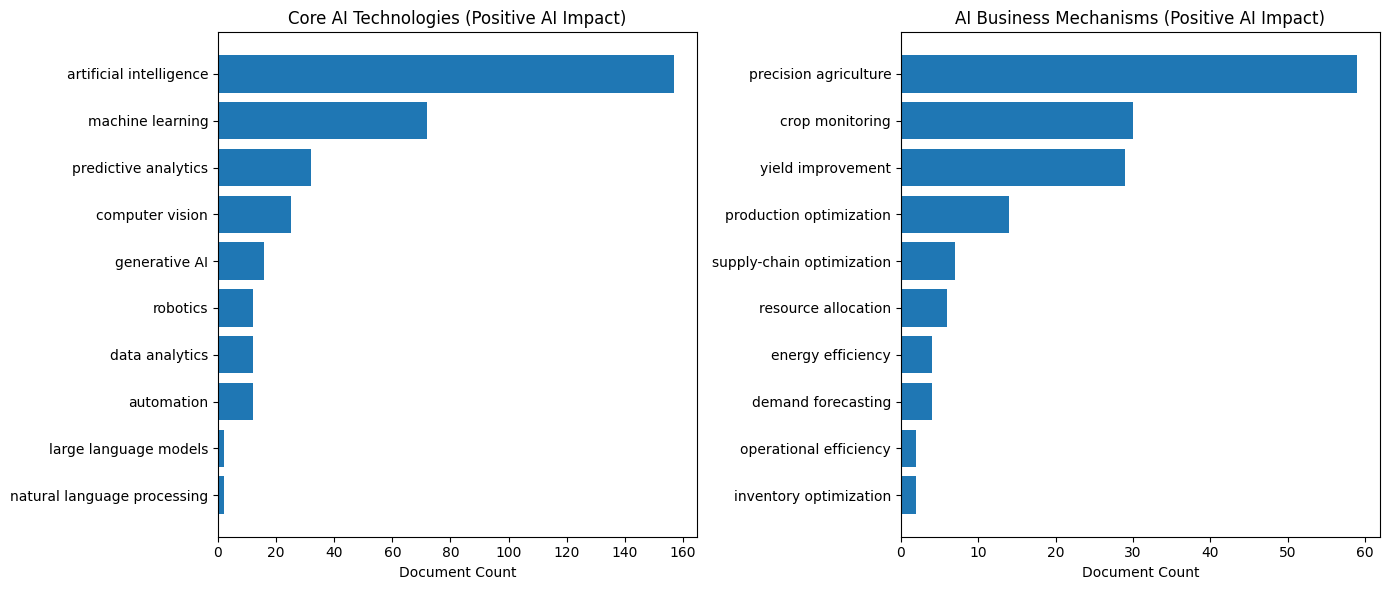

In [79]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Tradition - Negative impact

In [80]:
df_traditional_ner_neg = df_traditional_pred.loc[df_traditional_pred['pred_label'] == 'negatively'].reset_index(drop=True)
print(df_traditional_ner_neg.shape)

(30, 11)


In [81]:
neg_entity_system_msg = """\
You are an information extraction system for traditional physical production related news articles.

The user will provide a text block from a traditional production related article.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or companies in the traditional production ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS
Extract named companies, producers, manufacturers, agricultural firms, drilling or mining companies,
oil and gas operators, food producers, chemicals companies, industrial materials firms, machinery firms,
logistics firms, or other organizations explicitly stated in the text that are relevant to the traditional
production ecosystem.

This may include:
- agriculture and farming companies
- food and beverage producers
- drilling, mining, and mineral extraction companies
- oil and gas operators
- chemicals and industrial materials firms
- construction materials companies
- textile and apparel manufacturers
- machinery and conventional manufacturing firms
- supply-chain or logistics companies linked to production


## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:

- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE traditional production impact mechanisms explicitly mentioned in the text


Examples of technologies / capabilities:
- artificial intelligence
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- robotics
- industrial automation
- smart manufacturing
- predictive maintenance
- quality inspection
- autonomous systems


Examples of NEGATIVE traditional production impact mechanisms:
- job displacement
- labor reduction
- failed automation rollout
- implementation burden
- workflow disruption
- production disruption
- equipment downtime
- faulty forecasting
- defective inspection
- quality-control failure
- environmental risk
- supply-chain instability
- unreliable AI systems
- maintenance failures
- unequal access to AI tools


## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides in traditional production industries.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the producer”, “the manufacturer”, “farmers”,
  “miners”, “operators”, or “the industry” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [83]:
tradition_negative_impact_ner = []

for idx, row in df_traditional_ner_neg.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    tradition_negative_impact_ner.append(result)
    
df_tradition_negative_impact_ner_result = pd.DataFrame(tradition_negative_impact_ner)

##### Organization

In [86]:
df_negorg_long = (
    df_tradition_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_raw_counts
# negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
# print(negorg_candidates.shape)
# negorg_candidates

(12, 2)


,entity_raw,raw_count
0,International Federation of Robotics,2
1,BharatAgri,1
2,Evogene,1
3,Digital Agriculture Lab,1
4,Federal Aviation Administration (FAA),1
5,ICL,1
6,International Food Policy Research Institute,1
7,LSMS-ISA,1
8,Lavie Bio,1
9,U.S. Department of Agriculture,1


##### Tech and Mech

In [87]:
df_ai_mech_long_neg = (
    df_tradition_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(76, 2)
(12, 2)


,entity_raw,raw_count
0,artificial intelligence,15
1,machine learning,10
2,robotics,4
3,AI,3
4,deep learning,2
5,generative AI,2
6,robotic harvesters,2
7,generative AI algorithms,2
8,autonomous tractors,2
9,AI algorithms,2


In [88]:
neg_candidate_pairs = list( neg_ai_mech_raw_counts[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

'- (artificial intelligence, 15)\n- (machine learning, 10)\n- (robotics, 4)\n- (AI, 3)\n- (deep learning, 2)\n- (generative AI, 2)\n- (robotic harvesters, 2)\n- (generative AI algorithms, 2)\n- (autonomous tractors, 2)\n- (AI algorithms, 2)\n- (smart farming technologies, 2)\n- (predictive analytics, 2)\n- (AI-powered machines, 1)\n- (AI-powered irrigation systems, 1)\n- (AI-powered drones, 1)\n- (AI-powered drone solutions, 1)\n- (AI-driven program, 1)\n- (AI-driven predictive crop growth models, 1)\n- (AI-driven irrigation system, 1)\n- (AI-Powered Crop Monitoring, 1)\n- (AI systems, 1)\n- (AI adoption, 1)\n- (computer vision, 1)\n- (computer modelling, 1)\n- (cloud-based analytics, 1)\n- (automated irrigation tool, 1)\n- (artificial intelligence (AI), 1)\n- (MicroBoost AI tech-engine, 1)\n- (data-quality awareness, 1)\n- (data-driven agriculture, 1)\n- (data management, 1)\n- (decision trees, 1)\n- (digital technologies, 1)\n- (drone, 1)\n- (decreased reliability, 1)\n- (digital lit

In [89]:
neg_mech_top_system_msg = """\
You are an AI technology and traditional production impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from traditional production industry AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_traditional_production_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI traditional production negative impact mechanisms


Definitions:


### core_ai_technology
Fundamental AI technologies, models, or technical approaches used in industrial and production systems.

Examples include:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- robotics
- industrial automation
- smart manufacturing


### ai_traditional_production_mechanism
Operational, production, logistics, agricultural, extraction, or manufacturing mechanisms
through which AI negatively affects traditional physical production industries.

Focus especially on negative impact mechanisms, risks, harms, and downsides in traditional production.


### other
Anything vague, unclear, or not clearly an AI technology or traditional production mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_traditional_production_mechanism when the traditional production context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

In [90]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [91]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,artificial intelligence,19,"[artificial intelligence, AI, artificial intel..."
1,machine learning,16,"[machine learning, deep learning, machine lear..."
2,generative AI,4,"[generative AI, generative AI algorithms]"
3,robotics,4,[robotics]
4,predictive analytics,3,"[predictive analytics, predictive analysis]"
5,computer vision,2,"[computer vision, computer modelling]"
6,drones,2,"[drone, drones]"
7,AI algorithms,2,[AI algorithms]
8,smart farming technologies,2,[smart farming technologies]
9,robotic harvesters,2,[robotic harvesters]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,job loss due to automation,1,[job loss due to automation]
1,high initial costs,1,[high initial costs]
2,labor costs,1,[labor costs]
3,labor shortages,1,[labor shortages]
4,skill gaps,1,[skill gaps]
5,decreased reliability,1,[decreased reliability]
6,struggled to consistently provide robust results,1,[struggled to consistently provide robust resu...
7,trust in forecasts,1,[trust in forecasts]
8,underutilise them,1,[underutilise them]
9,integration with existing systems,1,[integration with existing systems]


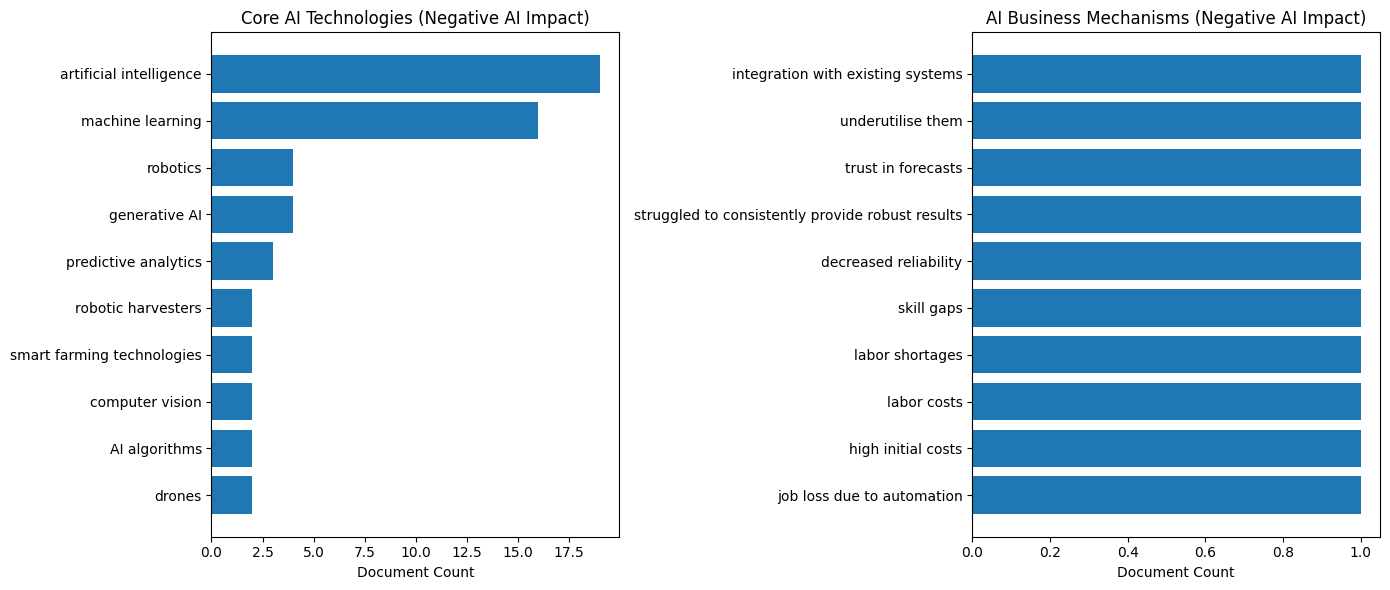

In [92]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [93]:
df_high_tech_pred = pd.read_parquet(f"{DATA_DIR}/phy_prod_models/phyprod_hightech_classifier_predictions.parquet")
df_traditional_pred  = pd.read_parquet(f"{DATA_DIR}/phy_prod_models/phyprod_tradition_classifier_predictions.parquet")

#### Topic Aggregation

In [94]:
Industry_topics = pd.read_csv(f"{DATA_DIR}/Phy_Prod_specific/Phy_Prod_topics.csv")

In [95]:
display(Industry_topics.head(2))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,155,-1_symbols_smart portfolio_cores_tipranks,"['symbols', 'smart portfolio', 'cores', 'tipra...","[""Create your Watchlist to save your favorite ..."
1,0,4484,0_air conditioners_conditioners_uhd_qned,"['air conditioners', 'conditioners', 'uhd', 'q...",['LG 55 Inch C2 Series 4K Smart SELF-LIT OLED ...


##### High tech

In [96]:
ai_impact_topic_id = [2, 3, 8, 9, 10, 11, 12]
ai_impact_topics = Industry_topics[Industry_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
3,2,"['mobility', 'fleet', 'automotive industry', '...",['Stellantis deepens AI investment with in-car...
4,3,"['huawei', 'chips china', 'export controls', '...",['Chinese firms are scrambling to buy Nvidia\'...
9,8,"['taiwan semiconductor', 'asml', 'motley', 'fo...","[""Don’t miss out on the latest top 10 list, av..."
10,9,"['optimus', 'self-driving', 'humanoid', 'fsd',...",['Watch: Elon Musk showcases humanoid robot at...
11,10,"['hynix', 'trillion won', 'dram', 'memory chip...",['SK Hynix says AI boom will drive profits aft...
12,11,"['pixel pro', 'google pixel', 'pixel pixel', '...",['Google unveils new phone injected with more ...
13,12,"['core ultra', 'xeon', 'gaudi', 'meteor lake',...",['Intel متعارف ڪرايو نئون AI چپس، Gaudi3 ۽ ڪور...


In [97]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in ai_impact_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

ai_impact_topics["topic_summary"] = summaries
show_full(ai_impact_topics[["Topic", "topic_summary"]])

,Topic,topic_summary
3,2,This topic focuses on the digital transformation and technological innovation within the automotive industry and its mobility services.
4,3,U.S. export controls on advanced AI chips to China over national security concerns.
9,8,Investment advice from The Motley Fool on semiconductor stocks like Taiwan Semiconductor Manufacturing.
10,9,Tesla's Optimus humanoid robot and its self-driving technology ambitions.
11,10,SK Hynix's financial recovery and AI memory chip leadership amid industry downturn.
12,11,"Google's new Pixel smartphones, emphasizing AI integration and features like Bard."
13,12,"Intel's new AI-focused chips, including Core Ultra, Xeon, and Gaudi3, for generative AI and PCs."


In [98]:
df_high_tech_pred["doc_id"] = df_high_tech_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_high_tech_pred["doc_id"] = df_high_tech_pred["doc_id"].astype(int)

display(df_high_tech_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,46_0_0_0_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"""Export control was a failure."" Nvidia CEO Jen...",negatively,0.558900,0.55890,0.167321,0.273778,46
1,46_1_0_9_0,https://www.tomshardware.com/tech-industry/sem...,2025-05-26,"""Export control was a failure."" Nvidia CEO Jen...",3,"So there are lots of startups in China, GPU co...",positively,0.585994,0.08817,0.325836,0.585994,46


In [99]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_high_tech_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,2,603.0,0.0,529.0
1,3,133.0,577.0,209.0
2,8,121.0,16.0,222.0
3,9,139.0,2.0,194.0
4,10,33.0,14.0,221.0
5,11,80.0,2.0,173.0
6,12,1.0,0.0,150.0


pred_label,topic,hard-to-say,negatively,positively
0,2,53.27%,0.0%,46.73%
1,3,14.47%,62.79%,22.74%
2,8,33.7%,4.46%,61.84%
3,9,41.49%,0.6%,57.91%
4,10,12.31%,5.22%,82.46%
5,11,31.37%,0.78%,67.84%
6,12,0.66%,0.0%,99.34%


In [100]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,2,0.532686,0.000000,0.467314,0.467314
1,3,0.144723,0.627856,0.227421,-0.400435
2,8,0.337047,0.044568,0.618384,0.573816
3,9,0.414925,0.005970,0.579104,0.573134
4,10,0.123134,0.052239,0.824627,0.772388
5,11,0.313725,0.007843,0.678431,0.670588
6,12,0.006623,0.000000,0.993377,0.993377


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [101]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.73, 0.09, 0.18],
    [0.00, 0.80, 0.20],
    [0.00, 0.20, 0.80]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,2,0.554476,0.000000,0.445524,0.445524
1,3,0.065552,0.860077,0.074371,-0.785706
2,8,0.239605,0.061052,0.699342,0.638290
3,9,0.359708,0.008178,0.632113,0.623935
4,10,0.000000,0.066781,0.933219,0.866438
5,11,0.191512,0.010744,0.797744,0.787000
6,12,0.000000,0.000000,1.000000,1.000000


##### Traditional

In [105]:
ai_impact_topic_id = [4,7]
ai_impact_topics = Industry_topics[Industry_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
5,4,"['farmers', 'crop', 'farming', 'agricultural',...",['It also gives the soil status and how much w...
8,7,"['drill', 'drilling', 'exploration', 'samples'...",['Drill hole SF21-005C is projected into the s...


In [106]:
df_traditional_pred["doc_id"] = df_traditional_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_traditional_pred["doc_id"] = df_traditional_pred["doc_id"].astype(int)

display(df_traditional_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,810_0_0_0_0,https://timesofindia.indiatimes.com/business/i...,2025-10-07,'Mine baby mine': Trump approves Alaska mining...,7,'Mine baby mine': Trump approves Alaska mining...,hard-to-say,0.889170,0.021893,0.889170,0.088936,810
1,1573_0_0_0_0,https://www.ruetir.com/2023/10/10-technologies...,2023-10-17,10 Technologies Made in Israel that We Unknowi...,4,10 Technologies Made in Israel that We Unknowi...,hard-to-say,0.855277,0.016741,0.855277,0.127982,1573


In [108]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_traditional_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,4,290.0,24.0,137.0
1,7,139.0,0.0,52.0


pred_label,topic,hard-to-say,negatively,positively
0,4,64.3%,5.32%,30.38%
1,7,72.77%,0.0%,27.23%


In [109]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,4,0.643016,0.053215,0.303769,0.250554
1,7,0.727749,0.000000,0.272251,0.272251


In [110]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.78, 0.11, 0.11],
    [0.00, 0.95, 0.05],
    [0.00, 0.33, 0.67]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,4,0.529072,0.068224,0.402703,0.334479
1,7,0.641530,0.000000,0.358470,0.358470


#### Time Aggregation

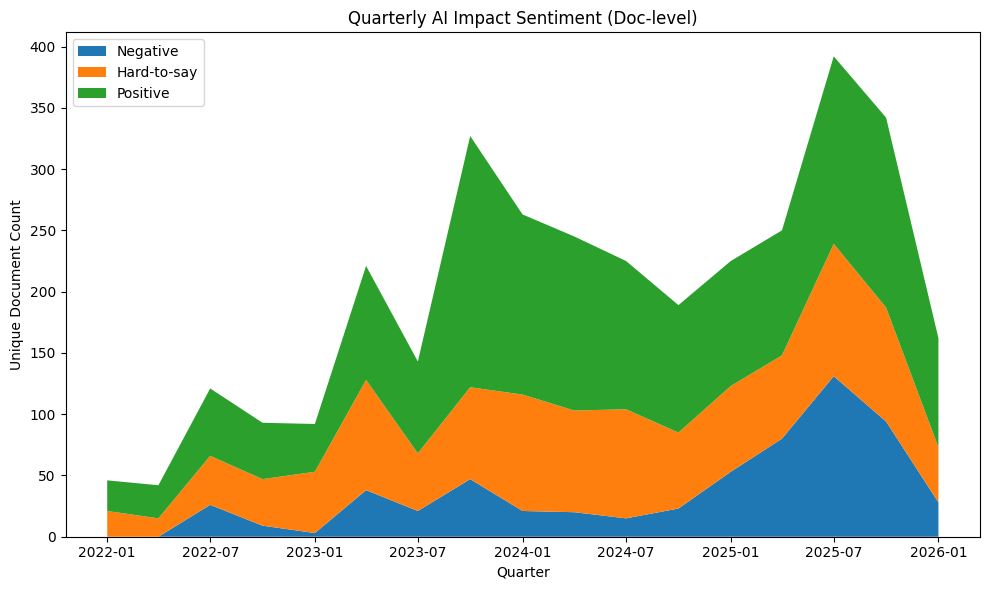

In [111]:
df_high_tech_pred["date"] = pd.to_datetime(df_high_tech_pred["date"])
df_high_tech_pred["quarter"] = df_high_tech_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_high_tech_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

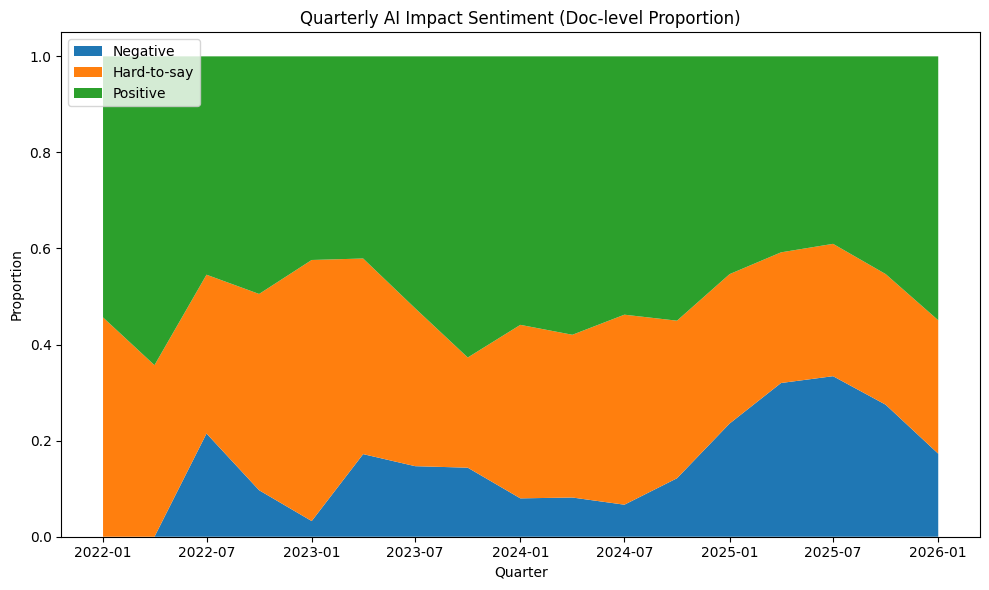

In [112]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

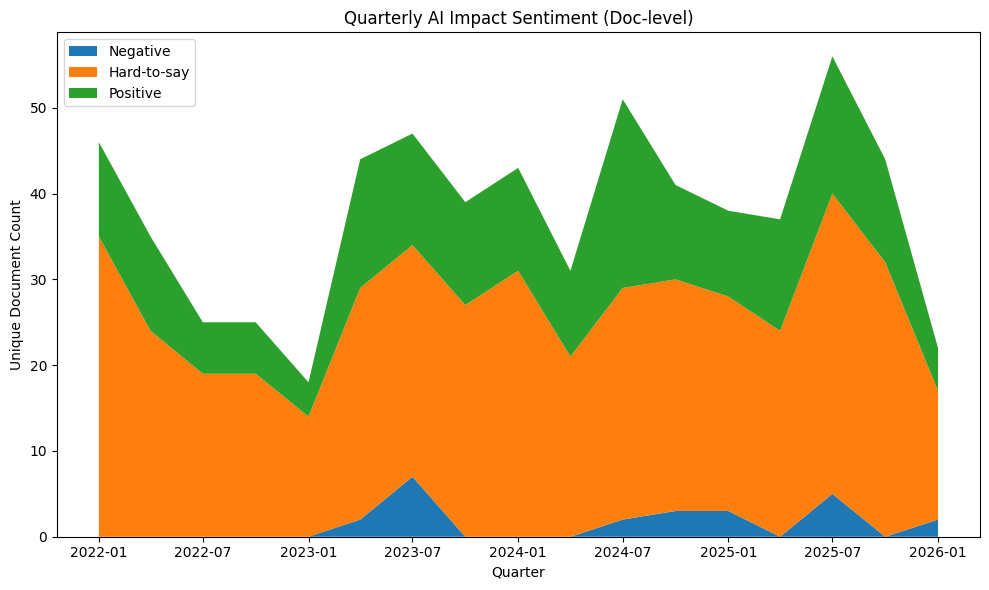

In [114]:
df_traditional_pred["date"] = pd.to_datetime(df_traditional_pred["date"])
df_traditional_pred["quarter"] = df_traditional_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_traditional_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

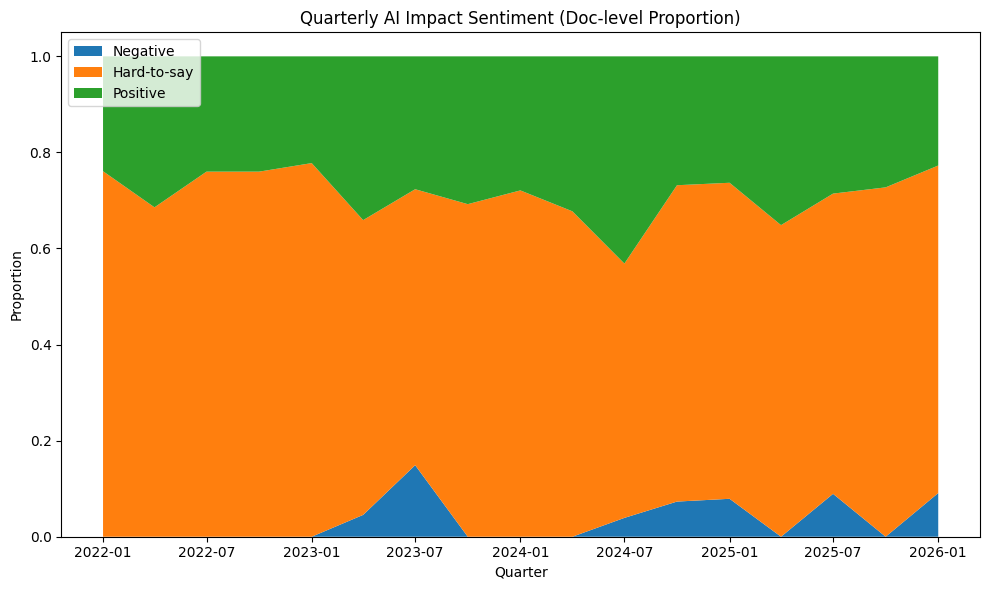

In [115]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()